# Warmtevraag Leuven — heat demand profile

Builds an hourly heat-demand profile for Leuven centrum, to be used as input for city-scale collective borefield sizing (see `BorefieldSizingLeuven_v1.ipynb`).

**Data sources**
- Per-statistical-sector yearly heat demand (2023): Flanders WFS layer `er:er_wrmtk_wvrg_statsec_2023`.
- Hourly shape: Fluvius public sample of 300 residential gas meters for 2024 (`P6269_1_50_DMK_Sample_Gas_2024.csv`), normalized to a profile that sums to 1 over the year and used to distribute the yearly totals over hours.

**Scope**: filtered to statistical sectors starting with `24062A` (Leuven centrum) — a deliberate scope choice, not the full merged municipality (which would also include Kessel-Lo, Heverlee, Wilsele, Wijgmaal).

**Cases** (all three are computed here):
- **a**: current worst-worst-case — residential-shaped hourly profile scaled by the *combined* kv (residential) + industrial demand, heating only.
- **b**: kv-only — same residential shape, scaled by `wv_kv_tot_mwh` only.
- **c**: more realistic — kv scaled by the residential shape, industry (`tot_warmtevraag_gv_mwh`) spread flat instead of residential-shaped, plus an assumed cooling load (no real cooling data — see the case c docstring in `build_hourly_heat_demand` for the literature assumption used).

Output: `load_profile_case_a.parquet`, `load_profile_case_b.parquet`, `load_profile_case_c.parquet` — hourly heat demand in kWh/h (case c also has a `cooling_demand_kWh` column).


In [ ]:
import pathlib

import geopandas as gpd
import numpy as np
import pandas as pd

DATA_DIR = pathlib.Path(r"C:\Workdir\Develop\ghetool\UrbanLab")


In [2]:
wfs_url = (
"https://www.mercator.vlaanderen.be/raadpleegdienstenmercatorpubliek/wfs?service=WFS&version=2.0.0&request=GetFeature&typeNames=er:er_wrmtk_wvrg_statsec_2023&outputFormat=application/json")
gdf = gpd.read_file(wfs_url)

Filter to Leuven centrum (statistical sectors starting with `24062A`) — see scope note above.

Index(['id', 'fid', 'statsec_naam', 'statsec_code', 'relevante_weg_lengte_m',
       'aantal_gas_ap', 'aantal_elek_ap', 'tot_gasverbruik_mwh',
       'tot_elektriciteitsverbruik_mwh',
       'aantal_aansluitingen_wv_bijschatting', 'aantal_aansluitingen_wv_gas',
       'aantal_aansluitingen_wv_elek', 'wv_bijschatting_mwh', 'wv_gas_mwh',
       'wv_elek_mwh', 'wv_kv_tot_mwh', 'ebo_gv_20_200gwh_jr',
       'ebo_gv_1_20gwh_jr', 'ebo_gv_onder_0_2gwh_jr', 'ebo_gv_0_2_1gwh_jr',
       'ebo_gv_boven_200gwh_jr', 'tot_warmtevraag_gv_ebo_mwh',
       'fluv_gv_0_2_1gwh_jr', 'fluv_gv_1_20gwh_jr', 'fluv_gv_20_200gwh_jr',
       'fluv_gv_boven_200gwh_jr', 'tot_aantal_kv',
       'tot_warmtevraag_gv_fluv_mwh', 'tot_warmtevraag_gv_mwh',
       'tot_warmtevraag_mwh', 'warmtevraagdichtheid_mwh_m', 'geometry'],
      dtype='str')

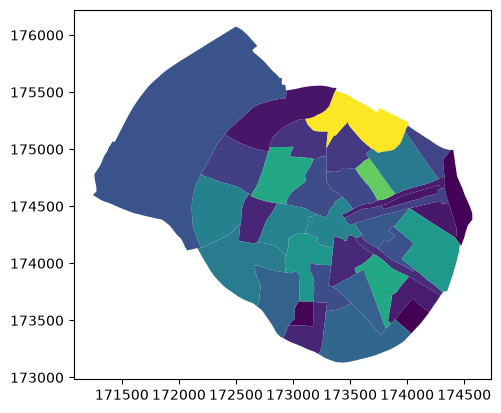

In [3]:
#statistische sectoren Leuven centrum beginnen met 24062A, dus we filteren de data op basis van deze code
verbruik_leuven= gdf[gdf.statsec_code.str.startswith("24062A")]
verbruik_leuven.plot('tot_warmtevraag_mwh')
verbruik_leuven.columns

In [4]:
# Fluvius voorbeeldprofielen: https://opendata.fluvius.be/explore/assets/1_50-verbruiksprofielen-dm-gas-uurwaarden-voor-een-volledig-jaar/
fluvius = pd.read_csv(DATA_DIR / "P6269_1_50_DMK_Sample_Gas_2024.csv")
fluvius.columns


Index(['EAN_ID', 'Datum', 'Datum_Startuur', 'Datum_Einduur',
       'Volume_Afname_KWh', 'Type_Gasmeter', 'Contract_Categorie'],
      dtype='str')

In [5]:
# Normalized hourly shape: fraction of the yearly total volume consumed in each hour,
# summed across all 300 sample meters. Dimensionless weights that sum to 1 over the year.
fluvius_res_profile_scaled = fluvius.groupby('Datum_Startuur').sum()[["Volume_Afname_KWh"]] / fluvius[["Volume_Afname_KWh"]].sum()
fluvius_res_profile_scaled


,Volume_Afname_KWh
Datum_Startuur,
2024-01-01T00:00:00.000Z,0.000110
2024-01-01T01:00:00.000Z,0.000105
2024-01-01T02:00:00.000Z,0.000116
2024-01-01T03:00:00.000Z,0.000090
2024-01-01T04:00:00.000Z,0.000096
...,...
2024-12-31T19:00:00.000Z,0.000325
2024-12-31T20:00:00.000Z,0.000298
2024-12-31T21:00:00.000Z,0.000265


## Build the hourly heat demand profile per case

`build_hourly_heat_demand` distributes the yearly sector totals over hours using the normalized Fluvius shape above. Only case `"a"` is implemented; `"b"` and `"c"` are stubs for later.


In [6]:
def build_hourly_heat_demand(fluvius_profile_normalized: pd.DataFrame, verbruik_leuven: gpd.GeoDataFrame, case: str = "a") -> pd.DataFrame:
    """Return the hourly heat demand profile [kWh/h] for the given case, indexed like fluvius_profile_normalized.

    case "a": worst-worst-case - residential-shaped profile scaled by the combined kv + industrial
              yearly demand (tot_warmtevraag_mwh), heating only.
    case "b": kv-only - residential-shaped profile scaled by the kv-only yearly demand (wv_kv_tot_mwh),
              heating only. Same shape as case a, smaller magnitude - drops the industrial component.
    case "c": more realistic - kv scaled by the residential shape (as in a/b), industry (tot_warmtevraag_gv_mwh)
              spread as a flat, constant hourly profile instead of the residential shape (no real industrial
              load-shape data available), plus a cooling load. There is no real cooling-demand data either;
              cooling energy is assumed to be 15% of the kv heating energy (a rough literature order-of-
              magnitude, not measured), distributed as a smooth raised-cosine seasonal profile peaking in
              July and zero outside a ~8-month cooling season. Returns two columns: "heat_demand_kWh"
              (extraction) and "cooling_demand_kWh" (injection).
    """
    if case == "a":
        total_mwh = verbruik_leuven.tot_warmtevraag_mwh.sum()
        return fluvius_profile_normalized * total_mwh * 1000  # MWh -> kWh
    elif case == "b":
        total_mwh = verbruik_leuven.wv_kv_tot_mwh.sum()
        return fluvius_profile_normalized * total_mwh * 1000  # MWh -> kWh
    elif case == "c":
        kv_mwh = verbruik_leuven.wv_kv_tot_mwh.sum()
        industry_mwh = verbruik_leuven.tot_warmtevraag_gv_mwh.sum()
        n_hours = len(fluvius_profile_normalized)

        kv_heating = (fluvius_profile_normalized.iloc[:, 0] * kv_mwh * 1000)  # kWh/h, residential-shaped
        industry_heating = pd.Series(industry_mwh * 1000 / n_hours, index=fluvius_profile_normalized.index)  # kWh/h, flat
        heating = kv_heating + industry_heating

        timestamps = pd.to_datetime(fluvius_profile_normalized.index)
        day_of_year = timestamps.dayofyear.to_numpy()
        peak_day, half_width = 200, 120  # raised-cosine bell: ~8-month season centred on day 200 (mid-July)
        seasonal_weight = np.clip(np.cos(np.pi * (day_of_year - peak_day) / half_width), 0, None)
        seasonal_weight = seasonal_weight / seasonal_weight.sum()
        cooling_mwh = 0.15 * kv_mwh  # literature assumption, not measured
        cooling = pd.Series(seasonal_weight * cooling_mwh * 1000, index=fluvius_profile_normalized.index)

        return pd.DataFrame({"heat_demand_kWh": heating, "cooling_demand_kWh": cooling})
    else:
        raise ValueError(f"Unknown case: {case!r}")


Text(0, 0.5, 'kWh/h')

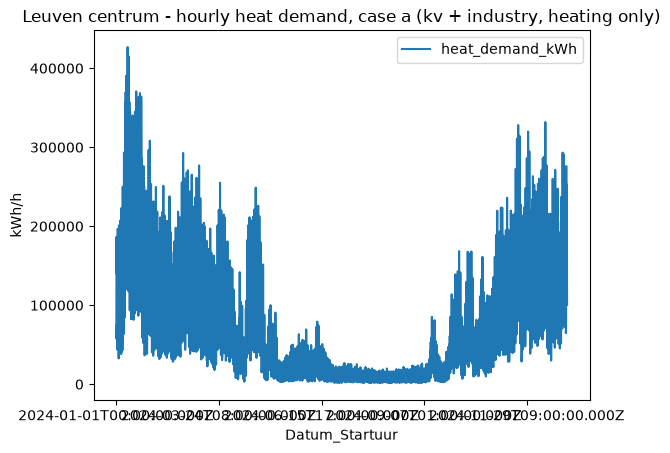

In [7]:
load_profile_case_a = build_hourly_heat_demand(fluvius_res_profile_scaled, verbruik_leuven, case="a")
load_profile_case_a.columns = ["heat_demand_kWh"]
ax = load_profile_case_a.plot(title="Leuven centrum - hourly heat demand, case a (kv + industry, heating only)")
ax.set_ylabel("kWh/h")


In [8]:
# Sanity check: total of the hourly profile should equal the yearly total pulled from the WFS layer
print(f"Yearly total (WFS, kv+industry): {verbruik_leuven.tot_warmtevraag_mwh.sum():.1f} MWh")
print(f"Yearly total (hourly profile):   {load_profile_case_a['heat_demand_kWh'].sum() / 1000:.1f} MWh")

out_path = DATA_DIR / "load_profile_case_a.parquet"
load_profile_case_a.to_parquet(out_path)
print(f"Saved to {out_path}")


Yearly total (WFS, kv+industry): 642688.9 MWh
Yearly total (hourly profile):   642688.9 MWh


Saved to C:\Users\u0169319\GHEtool\UrbanLab\load_profile_case_a.parquet


Text(0, 0.5, 'kWh/h')

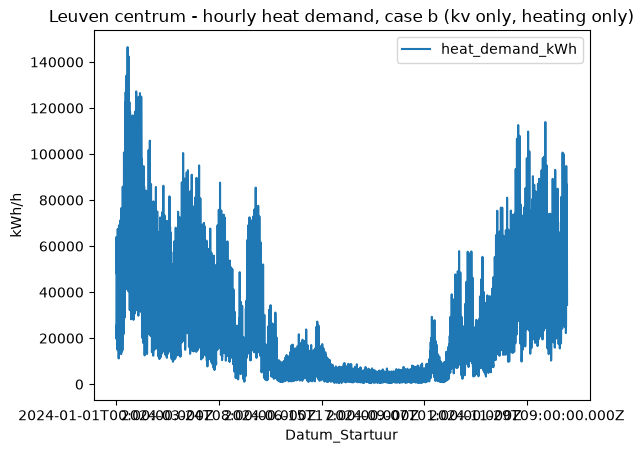

In [9]:
load_profile_case_b = build_hourly_heat_demand(fluvius_res_profile_scaled, verbruik_leuven, case="b")
load_profile_case_b.columns = ["heat_demand_kWh"]
ax = load_profile_case_b.plot(title="Leuven centrum - hourly heat demand, case b (kv only, heating only)")
ax.set_ylabel("kWh/h")


In [10]:
# Sanity check: total of the hourly profile should equal the yearly kv-only total pulled from the WFS layer
print(f"Yearly total (WFS, kv only): {verbruik_leuven.wv_kv_tot_mwh.sum():.1f} MWh")
print(f"Yearly total (hourly profile): {load_profile_case_b['heat_demand_kWh'].sum() / 1000:.1f} MWh")

out_path = DATA_DIR / "load_profile_case_b.parquet"
load_profile_case_b.to_parquet(out_path)
print(f"Saved to {out_path}")


Yearly total (WFS, kv only): 220588.9 MWh
Yearly total (hourly profile): 220588.9 MWh
Saved to C:\Users\u0169319\GHEtool\UrbanLab\load_profile_case_b.parquet


Text(0, 0.5, 'kWh/h')

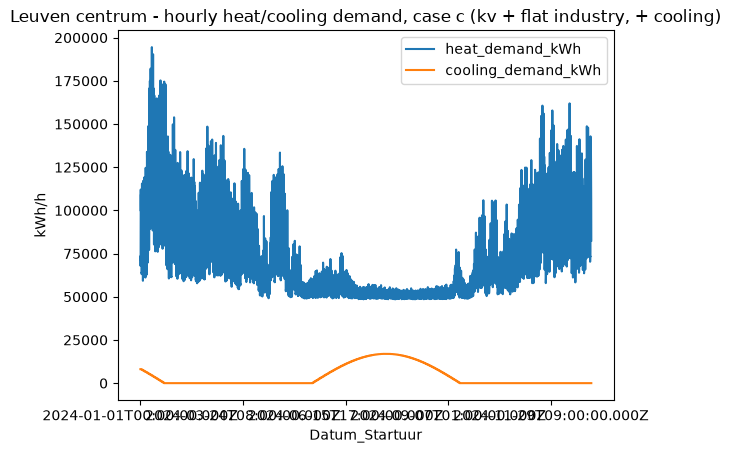

In [11]:
load_profile_case_c = build_hourly_heat_demand(fluvius_res_profile_scaled, verbruik_leuven, case="c")
ax = load_profile_case_c.plot(title="Leuven centrum - hourly heat/cooling demand, case c (kv + flat industry, + cooling)")
ax.set_ylabel("kWh/h")


In [12]:
# Sanity check: heating total should equal kv + industry yearly totals from the WFS layer; cooling total
# should equal the assumed 15% of kv.
kv_mwh = verbruik_leuven.wv_kv_tot_mwh.sum()
industry_mwh = verbruik_leuven.tot_warmtevraag_gv_mwh.sum()
print(f"Yearly heating total (WFS, kv + industry): {kv_mwh + industry_mwh:.1f} MWh")
print(f"Yearly heating total (hourly profile):     {load_profile_case_c['heat_demand_kWh'].sum() / 1000:.1f} MWh")
print(f"Yearly cooling total (assumed 15% of kv):  {0.15 * kv_mwh:.1f} MWh")
print(f"Yearly cooling total (hourly profile):     {load_profile_case_c['cooling_demand_kWh'].sum() / 1000:.1f} MWh")

out_path = DATA_DIR / "load_profile_case_c.parquet"
load_profile_case_c.to_parquet(out_path)
print(f"Saved to {out_path}")


Yearly heating total (WFS, kv + industry): 642688.9 MWh
Yearly heating total (hourly profile):     642688.9 MWh
Yearly cooling total (assumed 15% of kv):  33088.3 MWh
Yearly cooling total (hourly profile):     33088.3 MWh
Saved to C:\Users\u0169319\GHEtool\UrbanLab\load_profile_case_c.parquet
